In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 9.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [4]:
service = ctrl.Antecedent(np.arange(0, 10, 0.01), 'service')
quality = ctrl.Antecedent(np.arange(0, 10, 0.01), 'quality')
tip = ctrl.Consequent(np.arange(0, 30, 0.01), 'tip')

In [ ]:
help(fuzz.membership)

In [6]:
service['poor'] = fuzz.gaussmf(service.universe, 0, 1.2)
service['good'] = fuzz.gaussmf(service.universe, 5, 1.2)
service['excelent'] = fuzz.gaussmf(service.universe, 10, 1.2)

In [7]:
quality['rancid'] = fuzz.trapmf(quality.universe, [0,0,2,5])
quality['delicious'] = fuzz.trapmf(quality.universe, [5,8,10,10])

In [8]:
tip['low'] = fuzz.trimf(tip.universe, [0, 7.5, 15])
tip['medium'] = fuzz.trimf(tip.universe, [7.5, 15, 22.5])
tip['high'] = fuzz.trimf(tip.universe, [15, 22.5, 30])

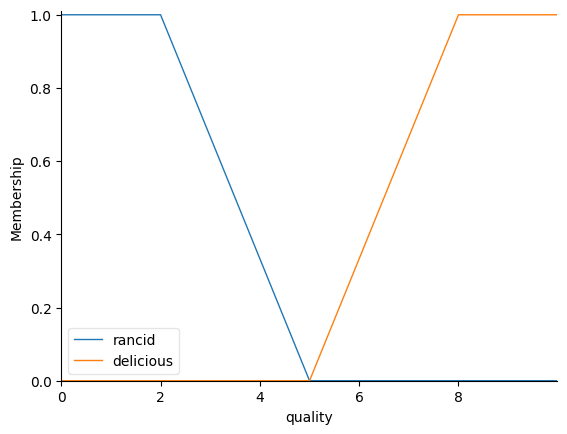

In [9]:
# You can see how these look with .view()
quality.view()

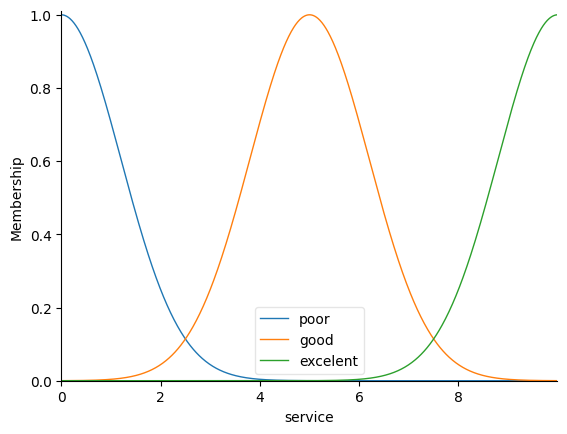

In [10]:
service.view()

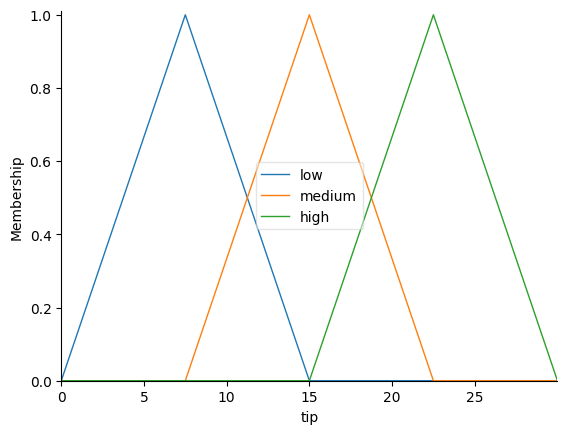

In [11]:
tip.view()

In [12]:
rule1 = ctrl.Rule(quality['rancid'] | service['poor'], tip['low'])
rule2 = ctrl.Rule(service['good'], tip['medium'])
rule3 = ctrl.Rule(service['excelent'] | quality['delicious'], tip['high'])


In [13]:
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])

In [14]:
tipping = ctrl.ControlSystemSimulation(tipping_ctrl)

In [15]:
# Pass inputs to the ControlSystem using Antecedent labels with Pythonic API
# Note: if you like passing many inputs all at once, use .inputs(dict_of_data)
tipping.input['quality'] = 6
tipping.input['service'] = 5

In [16]:
# Crunch the numbers
tipping.compute()

17.498239587686133


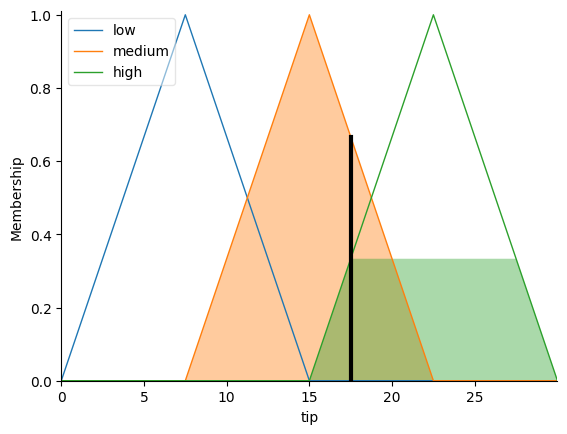

In [17]:
print(tipping.output['tip'])
tip.view(sim=tipping)

########################################################################################

Salary task

In [18]:
# Define fuzzy input variables
education = ctrl.Antecedent(np.arange(0, 16, 0.01), 'education')
experience = ctrl.Antecedent(np.arange(0, 31, 0.01), 'experience')

# Define fuzzy output variable
salary = ctrl.Consequent(np.arange(20000, 210000, 10), 'salary')

In [19]:
# Define Gaussian membership functions for education (Figure 3.9a)
education['low'] = fuzz.gaussmf(education.universe, 2, 2)
education['medium'] = fuzz.gaussmf(education.universe, 8, 3)
education['high'] = fuzz.gaussmf(education.universe, 13, 2)

# Define Gaussian membership functions for experience (Figure 3.9b)
experience['low'] = fuzz.gaussmf(experience.universe, 3, 4)
experience['medium'] = fuzz.gaussmf(experience.universe, 15, 5)
experience['high'] = fuzz.gaussmf(experience.universe, 25, 4)

# Define Gaussian membership functions for salary (Figure 3.9c)
salary['very_low'] = fuzz.gaussmf(salary.universe, 30000, 10000)
salary['low'] = fuzz.gaussmf(salary.universe, 70000, 15000)
salary['medium'] = fuzz.gaussmf(salary.universe, 120000, 20000)
salary['high'] = fuzz.gaussmf(salary.universe, 160000, 15000)
salary['very_high'] = fuzz.gaussmf(salary.universe, 190000, 10000)

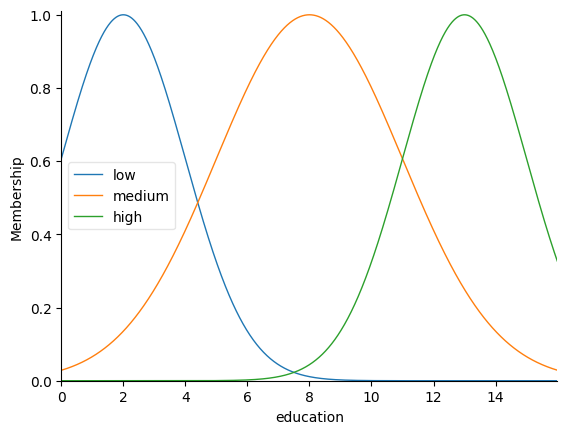

In [20]:
education.view()

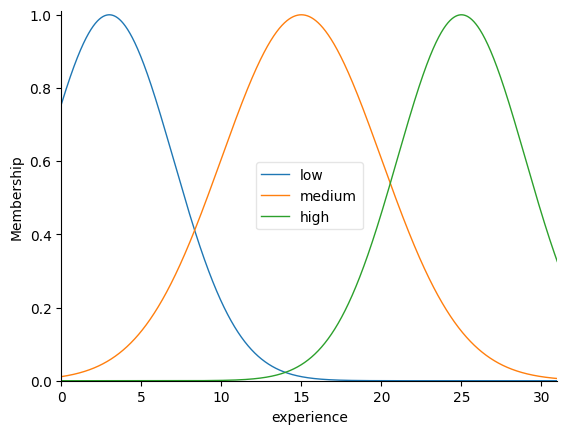

In [21]:
experience.view()

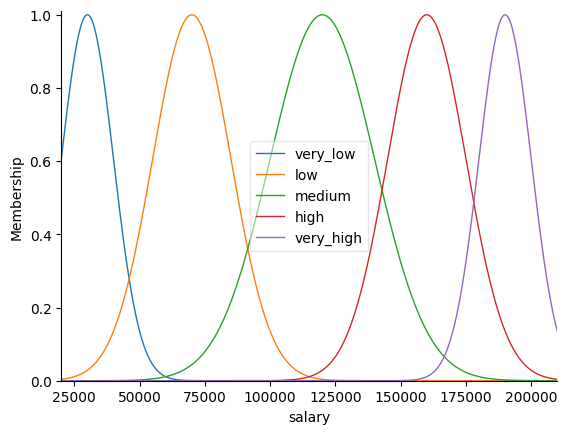

In [22]:
salary.view()

In [23]:
# Define fuzzy rules (from page 74)
rule1 = ctrl.Rule(education['low'] & experience['low'], salary['very_low'])
rule2 = ctrl.Rule(education['low'] & experience['medium'], salary['low'])
rule3 = ctrl.Rule(education['low'] & experience['high'], salary['medium'])
rule4 = ctrl.Rule(education['medium'] & experience['low'], salary['low'])
rule5 = ctrl.Rule(education['medium'] & experience['medium'], salary['medium'])
rule6 = ctrl.Rule(education['medium'] & experience['high'], salary['high'])
rule7 = ctrl.Rule(education['high'] & experience['low'], salary['medium'])
rule8 = ctrl.Rule(education['high'] & experience['medium'], salary['high'])
rule9 = ctrl.Rule(education['high'] & experience['high'], salary['very_high'])

In [24]:
# Create the fuzzy control system
salary_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
salary_prediction = ctrl.ControlSystemSimulation(salary_ctrl)

In [25]:
# Example: Evaluate the system for education = 10 years and experience = 18 years
salary_prediction.input['education'] = 10
salary_prediction.input['experience'] = 18

# Compute the output
salary_prediction.compute()

# Print the result
print(f"Predicted salary: ${salary_prediction.output['salary']:.2f}")

Predicted salary: $133564.13


In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [30]:
# Function to generate 3D plot
def plot_fuzzy_surface():
    # Create grid for education and experience
    edu_values = np.linspace(0, 15, 30)
    exp_values = np.linspace(0, 30, 30)
    edu_grid, exp_grid = np.meshgrid(edu_values, exp_values)

    # Compute salary predictions
    salary_grid = np.zeros_like(edu_grid)

    for i in range(edu_grid.shape[0]):
        for j in range(edu_grid.shape[1]):
            salary_prediction.input['education'] = edu_grid[i, j]
            salary_prediction.input['experience'] = exp_grid[i, j]
            salary_prediction.compute()
            salary_grid[i, j] = salary_prediction.output['salary']

    # Plot 3D surface
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(edu_grid, exp_grid, salary_grid, cmap='viridis', edgecolor='k')

    # Labels and title
    ax.set_xlabel("Education (years)")
    ax.set_ylabel("Experience (years)")
    ax.set_zlabel("Predicted Salary ($)", labelpad=8)
    ax.set_title("Fuzzy Inference System - Salary Prediction")

    # Add color bar
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()

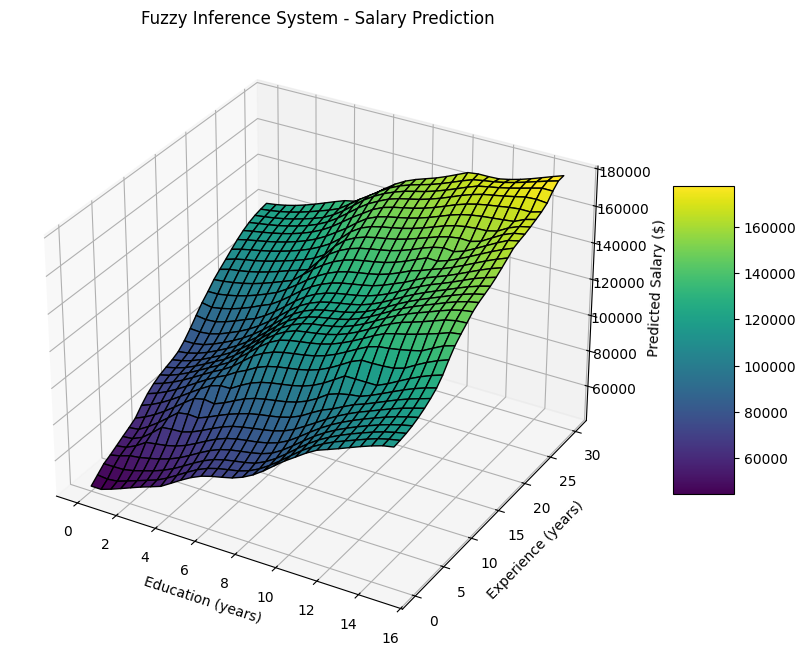

In [28]:
# Call the function to generate the 3D plot
plot_fuzzy_surface()